#
# Universidad EAFIT
# 2026-2
#
# Lab – Class 01 (Parte 1): Representación clásica del texto

Este notebook apoya la clase 01 del curso **Procesamiento de Lenguaje Natural Aplicado**.
Exploraremos técnicas fundamentales de preprocesamiento y representación de texto:

### ejemplos:
- Carga de documentos
- Tokenización, stopwords, lematización
- Representación con Bag of Words y TF-IDF
- Cálculo de similitud entre documentos
- Visualización con PCA

In [34]:
#configuración en google colab
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [35]:
!pip3 install nltk
!pip3 install pandas
!pip3 install matplotlib

In [36]:
# Importación de librerías
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords, reuters
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# cargar las librerias necesarias
## 1. nltk para 'procesamiento natural del lenguaje'
## 2. pandas para procesamiento de dataframes, muy usado en preparación de datos
## 3. re - expresiones regulares
## 4. numpy, codecs, etc - otras

In [37]:
!ls 'gdrive/MyDrive/si7016-262/datasets/gutenberg-es/'

48903-0.txt	 isla-del-tesoro.txt  la-odisea.txt  pg47631.txt
don-quijote.txt  la-iliada.txt	      pg47287.txt    pg62627.txt


In [38]:
# directorios (path) de entrada y salida:
#
path_in="gdrive/MyDrive/si7016-262/datasets/gutenberg-es/"
path_out="gdrive/MyDrive/si7016-262/out/"
filenametxt='don-quijote.txt'
filenamecleantxt='don-quijote_clean.txt'
filenamecsv='don-quijote.csv'

In [39]:
# corpus de nltk para 'tokenizer' y 'stopwords'
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [40]:
# ejemplo de como nltk tokeniza:
texto="texto libre que permite crear     hiso20091iras epor--4 no s#e preocupe \n hola mundo cruel"
tokens = nltk.word_tokenize(texto)
print(len(tokens))
print(tokens)

17
['texto', 'libre', 'que', 'permite', 'crear', 'hiso20091iras', 'epor', '--', '4', 'no', 's', '#', 'e', 'preocupe', 'hola', 'mundo', 'cruel']


In [41]:
# note la estrategia de tokenizar con sentencias simples de python,
# ¿ cual le parece mejor?
# y note la diferencia entre .split() y .split(' ')
texto="texto libre que permite crear     hiso20091iras            epor--4 no s#e preocupe \n hola mundo cruel"
tokens = texto.split()
print(len(tokens))
print(tokens)
tokens = texto.split(' ')
print(len(tokens))
print(tokens)

13
['texto', 'libre', 'que', 'permite', 'crear', 'hiso20091iras', 'epor--4', 'no', 's#e', 'preocupe', 'hola', 'mundo', 'cruel']
29
['texto', 'libre', 'que', 'permite', 'crear', '', '', '', '', 'hiso20091iras', '', '', '', '', '', '', '', '', '', '', '', 'epor--4', 'no', 's#e', 'preocupe', '\n', 'hola', 'mundo', 'cruel']


In [42]:
# stopwords en nltk
from nltk.corpus import stopwords

stop_words_nltk = set(stopwords.words('spanish'))
stop_words_nltk_en = set(stopwords.words('english'))
print(len(stop_words_nltk_en))
print(stop_words_nltk_en)

198
{"hadn't", 'such', 'myself', 'doing', "haven't", 'am', "we've", 'theirs', 'hers', 'about', 'be', 'a', "he'd", 'own', 'more', 'its', 'the', 'this', 't', "that'll", 'down', 'it', 'isn', 'now', "isn't", 'each', "doesn't", 'against', 'mustn', 'both', 'having', 'ourselves', 'ma', 'again', 'then', 'to', "we're", "don't", 'shan', "i'm", 'very', 'wasn', 'too', 'all', 'my', "they've", 'didn', 'themselves', "you're", 'through', 'she', 'll', 'can', "you've", 'until', 'where', "shan't", 'we', 'have', 've', 'ours', 'other', "we'll", 'with', 'hasn', 'that', 'in', 'me', 'not', 'o', 'once', "it'll", "she's", 'itself', "mustn't", 'while', 'our', 'during', "you'd", 'will', "we'd", "she'd", 'couldn', 'does', 'before', "they'll", 'on', "they're", 'below', 'few', 'they', 'when', "mightn't", 'for', 'whom', 'y', 'had', 'are', 'won', 'how', 'off', "aren't", "won't", 'if', 'nor', 'at', "i've", "she'll", 'further', 'as', 'here', 'weren', 'them', 'shouldn', 'ain', 'or', 're', "didn't", 'same', 'wouldn', 'whi

In [43]:
# permite verificar en nltk si un token pertenece a diccionario de un idioma, en este caso a 'english'
from nltk.corpus import words as voc_en

x = len(voc_en.words())
print('tamaño del diccionario en inglés del nltk: ',x)

# verifica si una palabra pertenece al diccionario:
w = "house"
if (len(w) >1) and w.isalpha() and (w in voc_en.words()) and (w not in stop_words_nltk_en):
    print(w," true")
else:
    print(w," false")

w = "eafit"
if (len(w) >1) and w.isalpha() and (w in voc_en.words()) and (w not in stop_words_nltk_en):
    print(w," true")
else:
    print(w," false")

tamaño del diccionario en inglés del nltk:  236736
house  true
eafit  false


In [44]:
# leer un archivo de ejemplo en .txt
input_file = open(path_in+filenametxt, "r", encoding='iso-8859-1')
filedata = input_file.read()

In [45]:
# Tokenización de n-grams usando Scikit-learn

from sklearn.feature_extraction.text import CountVectorizer

# Texto de ejemplo
text = ["El gato está durmiendo tranquilamente en el sofá"]

# Crear un CountVectorizer con diferentes valores de n
vectorizer = CountVectorizer(ngram_range=(1, 3))  # Unigramas, bigramas y trigramas
X = vectorizer.fit_transform(text)

# Mostrar los n-grams generados
print("N-grams generados:", vectorizer.get_feature_names_out())
print("Matriz de conteo:\n", X.toarray())

N-grams generados: ['durmiendo' 'durmiendo tranquilamente' 'durmiendo tranquilamente en' 'el'
 'el gato' 'el gato está' 'el sofá' 'en' 'en el' 'en el sofá' 'está'
 'está durmiendo' 'está durmiendo tranquilamente' 'gato' 'gato está'
 'gato está durmiendo' 'sofá' 'tranquilamente' 'tranquilamente en'
 'tranquilamente en el']
Matriz de conteo:
 [[1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


In [46]:
# Tokenización de n-grams manual
def generate_ngrams(text, n):
    """
    Genera una lista de n-grams a partir de un texto.
    """
    tokens = text.split()  # Tokenización básica por espacios
    ngrams = [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    return ngrams

# Texto de ejemplo
text = "El gato está durmiendo tranquilamente en el sofá"

# Generar n-grams para diferentes valores de n
for n in range(1, 4):  # Unigramas, bigramas, trigramas
    print(f"{n}-grams:", generate_ngrams(text, n))

1-grams: ['El', 'gato', 'está', 'durmiendo', 'tranquilamente', 'en', 'el', 'sofá']
2-grams: ['El gato', 'gato está', 'está durmiendo', 'durmiendo tranquilamente', 'tranquilamente en', 'en el', 'el sofá']
3-grams: ['El gato está', 'gato está durmiendo', 'está durmiendo tranquilamente', 'durmiendo tranquilamente en', 'tranquilamente en el', 'en el sofá']


numero de palabras finales =  22840
[('don', 2652), ('quijote', 2180), ('sancho', 2148), ('ms', 2044), ('si', 1966), ('dijo', 1808), ('ser', 1293), ('tan', 1243), ('as', 1075), ('seor', 1063), ('respondi', 1063), ('bien', 1050), ('haba', 1034), ('merced', 900), ('pues', 865), ('qu', 849), ('sino', 694), ('dos', 684), ('caballero', 661), ('decir', 578)]


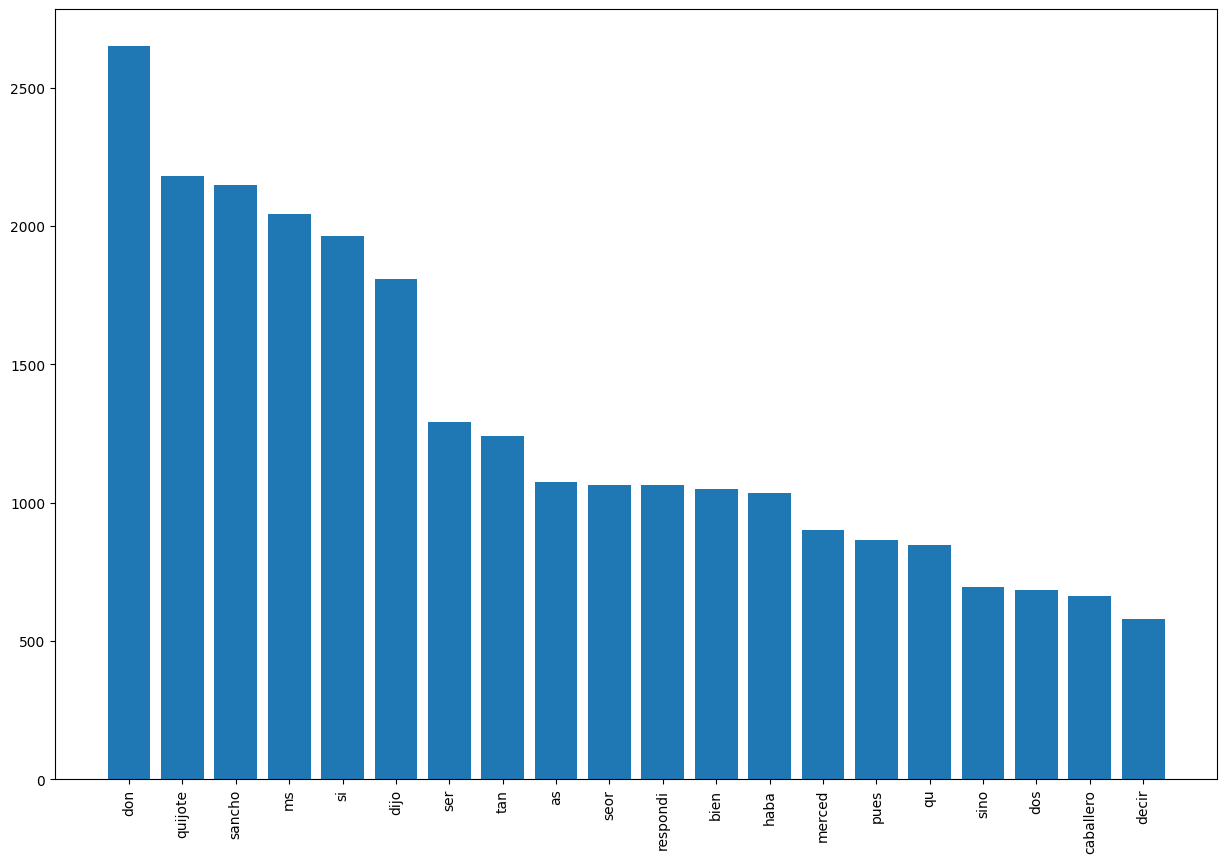

In [47]:
# opción 1:
# TOKENIZAR con .split(),
# ELIMINAR tokens de long = 1
# ELIMINAR caracteres que no sean alfanumericos y pasar todo a minuscula
# REMOVER stop words con nltk
# graficar los 20 términos más frecuentes:

tokens = filedata.split()
tokens = [re.sub(r'[^A-Za-z0-9]+','',w) for w in tokens]
# tokens=[word for word in tokens if word.isalpha()] si en vez de re.sub(r'[^A-Za-z0-9]+','',w) hace esto, que pasa?
tokens = [w.lower() for w in tokens if len(w)>1]
tokens = [w for w in tokens if w not in stop_words_nltk]

fdist = nltk.FreqDist(tokens)
print('numero de palabras finales = ',len(fdist))
topwords = fdist.most_common(20)
print (topwords)
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

numero de palabras finales =  22836
[('don', 2652), ('quijote', 2180), ('sancho', 2148), ('ms', 2044), ('si', 1966), ('dijo', 1808), ('ser', 1293), ('l', 1283), ('tan', 1243), ('as', 1075), ('seor', 1063), ('respondi', 1063), ('bien', 1050), ('haba', 1034), ('merced', 900), ('pues', 865), ('qu', 849), ('s', 742), ('sino', 694), ('dos', 684)]


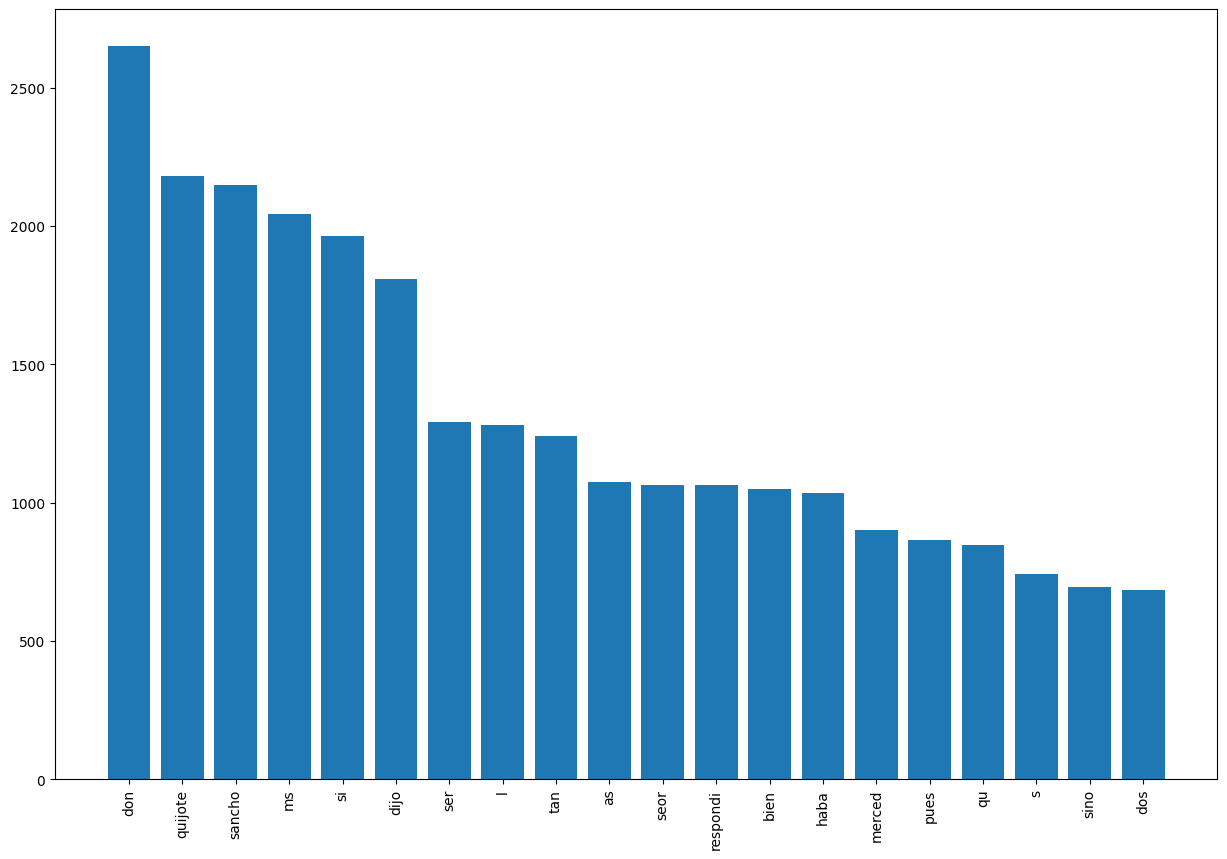

In [48]:
# opción 2:
# TOKENIZAR con nltk,
# ELIMINAR tokens de long = 1
# ELIMINAR caracteres que no sean alfanumericos
# REMOVER stop words
# graficar los 20 términos más frecuentes:

tokens = nltk.word_tokenize(filedata)
tokens = [w.lower() for w in tokens if len(w)>1]
tokens = [re.sub(r'[^A-Za-z0-9]+','',w) for w in tokens]
tokens = [w for w in tokens if w not in stop_words_nltk]

fdist = nltk.FreqDist(tokens)
topwords = fdist.most_common(20)
print('numero de palabras finales = ',len(fdist))
print (topwords)
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

numero de palabras finales =  17400


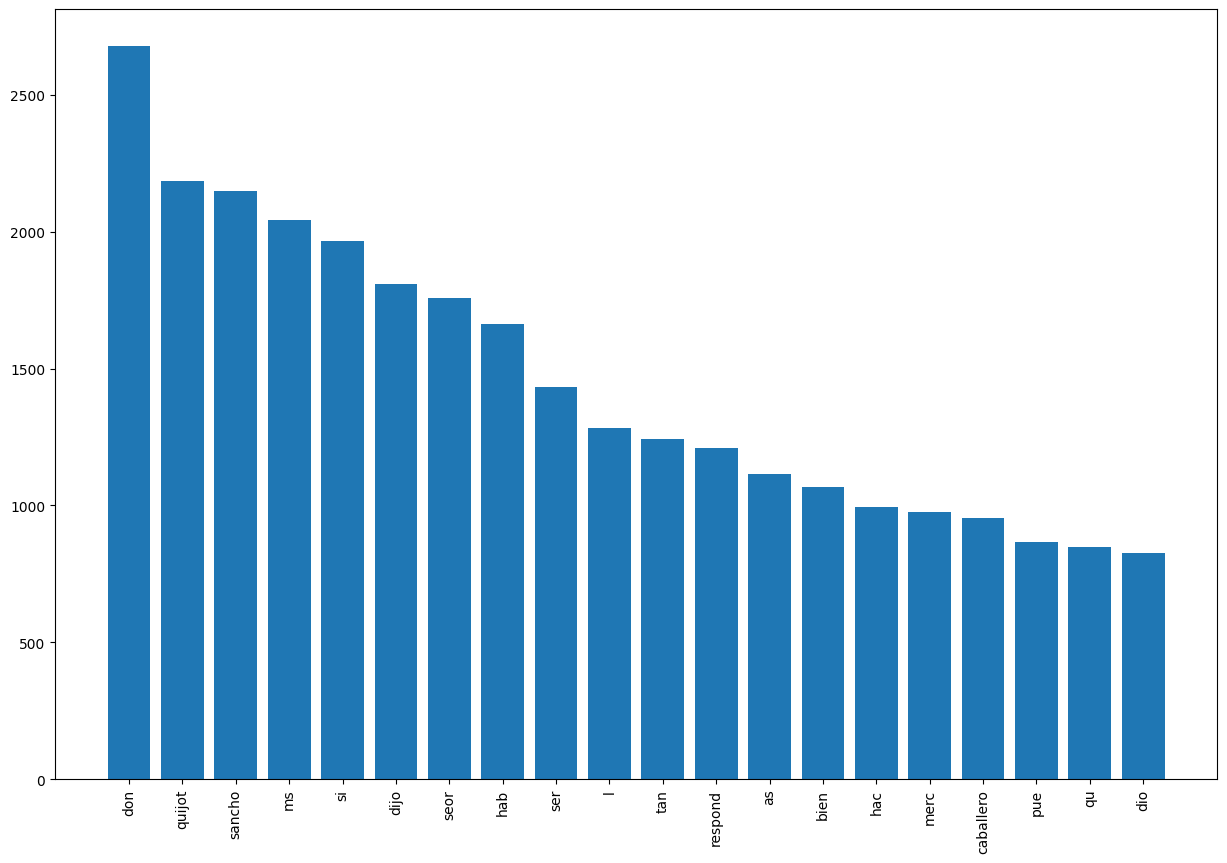

In [49]:
# Stemming con NLTK

from nltk.stem import PorterStemmer
from nltk.stem import LancasterStemmer

porter = PorterStemmer()
lancaster = LancasterStemmer()
# probar cada una de las siguientes opciones: porter y lancaster.
#tokens = [porter.stem(w) for w in tokens]
tokens = [lancaster.stem(w) for w in tokens]

fdist = nltk.FreqDist(tokens)
topwords = fdist.most_common(20)
print('numero de palabras finales = ',len(fdist))
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

numero de palabras finales =  17333


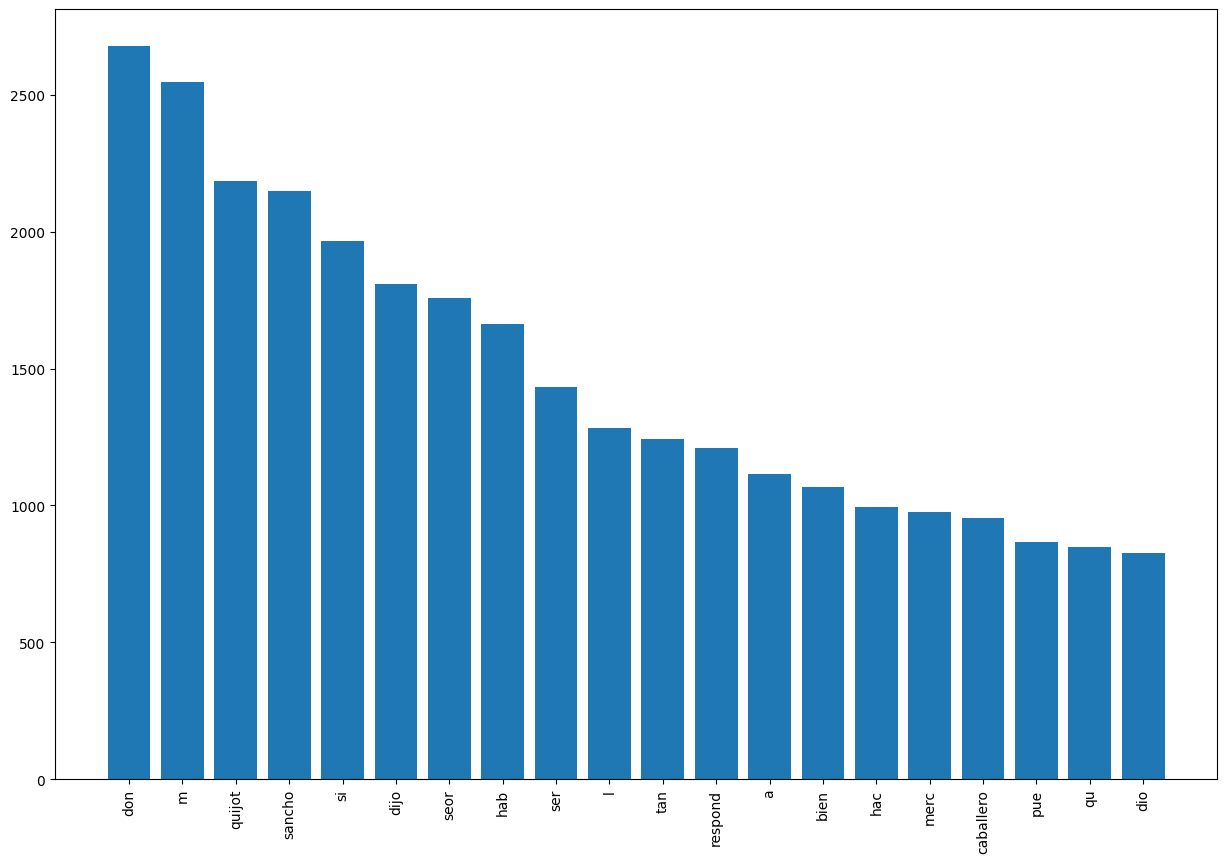

In [50]:
# Lemmatization con NLTK

from nltk.stem import WordNetLemmatizer

wordnet_lemmatizer = WordNetLemmatizer()

# probar cada una de las siguientes opciones:
#tokens = [wordnet_lemmatizer.lemmatize(w, pos="v") for w in tokens ]
tokens = [wordnet_lemmatizer.lemmatize(w) for w in tokens ]

fdist = nltk.FreqDist(tokens)
topwords = fdist.most_common(20)
print('numero de palabras finales = ',len(fdist))
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

In [51]:
# volver a leer el archivo ejemplo en .txt
#input_file = open(path_in+filenametxt, "r",encoding='iso-8859-1')
# VERIFIQUE QUE EL DIRECTORIO 'out' esta creado en: gdrive/MyDrive/si7016-262/
input_file = open(path_in+filenametxt, "r")
output_file_clean = open(path_out+filenamecleantxt, "w")

In [52]:
from nltk.stem import PorterStemmer
from nltk.stem import LancasterStemmer

porter = PorterStemmer()
lancaster = LancasterStemmer()
wordnet_lemmatizer = WordNetLemmatizer()

for line in input_file:
    line_clean = ""
    tokens = nltk.word_tokenize(line)
    tokens = [re.sub(r'[^A-Za-z0-9]+','',w) for w in tokens]
    tokens = [w.lower() for w in tokens if len(w)>1]
    tokens = [w for w in tokens if w.isalpha()]
    tokens = [w for w in tokens if w not in stop_words_nltk]
    #tokens = [wordnet_lemmatizer.lemmatize(w, pos="v") for w in tokens]
    tokens = [wordnet_lemmatizer.lemmatize(w) for w in tokens]

    #tokens = [porter.stem(w) for w in tokens]
    tokens = [lancaster.stem(w) for w in tokens]

    for w in tokens:
        line_clean=line_clean+w+" "

    if (line_clean!=""):
        line_clean=line_clean+"\n"
        output_file_clean.write(line_clean)
output_file_clean.close()

In [53]:
input_file_clean = open(path_out+filenamecleantxt, "r", encoding='iso-8859-1')

numero de palabras finales =  17270


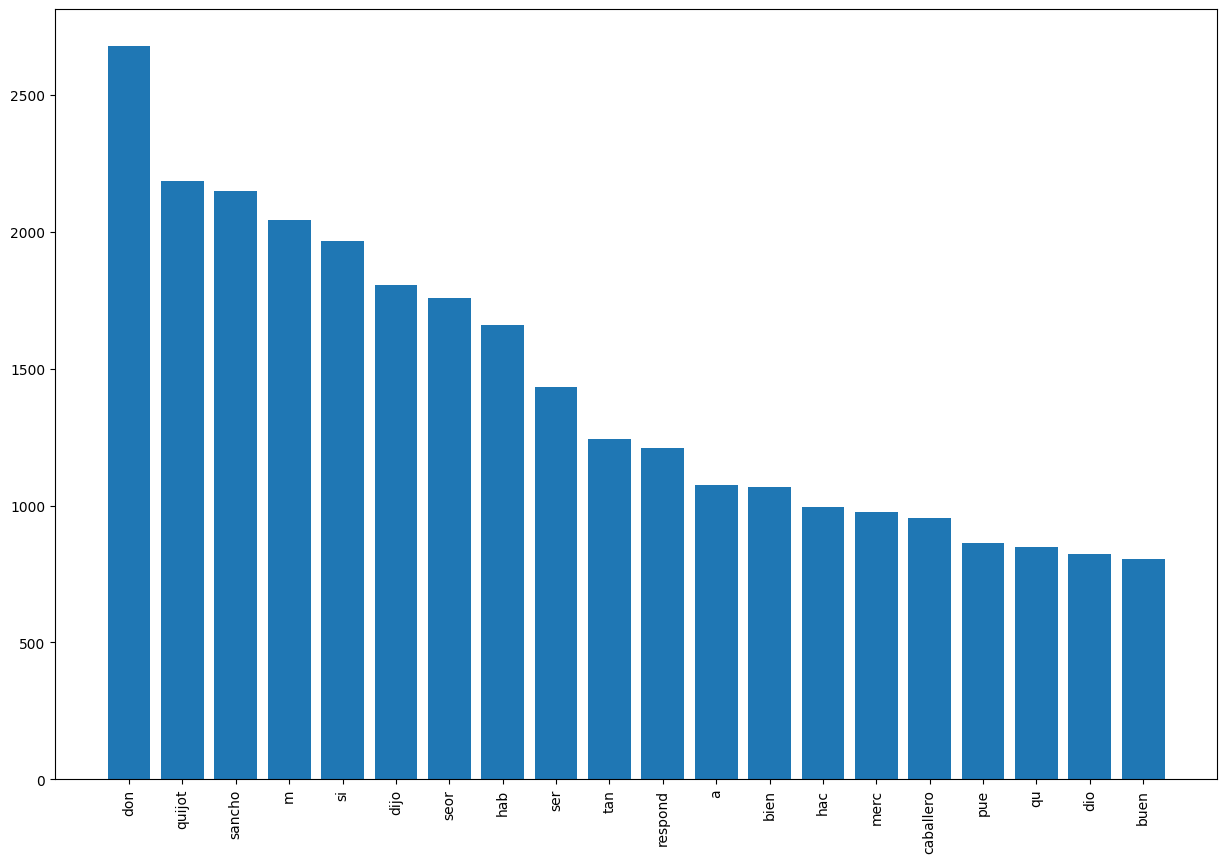

In [54]:
filedata = input_file_clean.read()
tokens = filedata.split()
fdist = nltk.FreqDist(tokens)
topwords = fdist.most_common(20)
print('numero de palabras finales = ',len(fdist))
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

In [55]:
word_freq = fdist.most_common(len(fdist))

In [56]:
import csv

with open(path_out+filenamecsv, 'w') as csvFile:
    writer = csv.writer(csvFile)
    writer.writerow(["word", "frecuency"])
    writer.writerows(word_freq)

csvFile.close()

In [57]:
# extract top 30 words
top_words = word_freq[:20]
print(top_words)

[('don', 2680), ('quijot', 2186), ('sancho', 2150), ('m', 2044), ('si', 1966), ('dijo', 1808), ('seor', 1758), ('hab', 1662), ('ser', 1433), ('tan', 1243), ('respond', 1211), ('a', 1075), ('bien', 1068), ('hac', 994), ('merc', 976), ('caballero', 954), ('pue', 865), ('qu', 849), ('dio', 825), ('buen', 805)]


In [58]:
import pandas as pd
df = pd.DataFrame(top_words)
df.head()

,0,1
0,don,2680
1,quijot,2186
2,sancho,2150
3,m,2044
4,si,1966


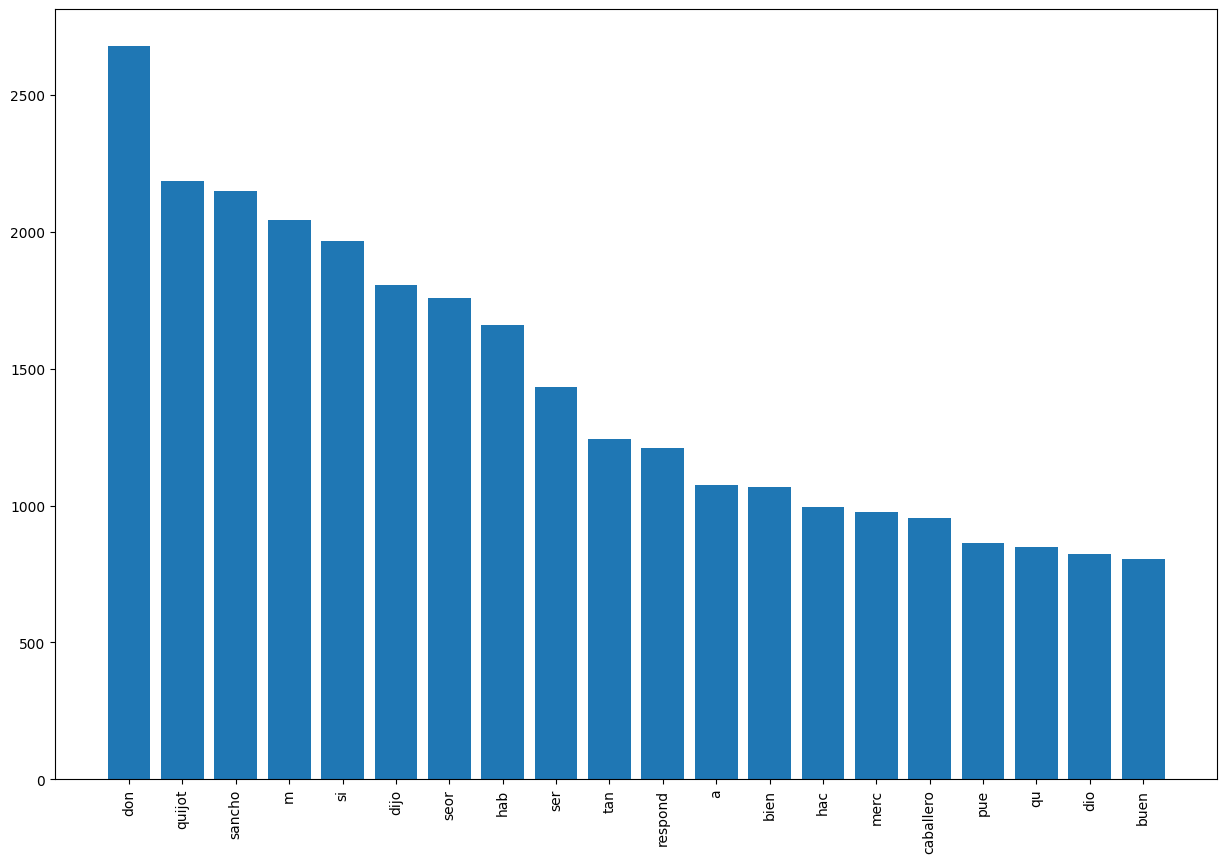

In [59]:
import matplotlib.pyplot as plt
x,y = zip(*top_words)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

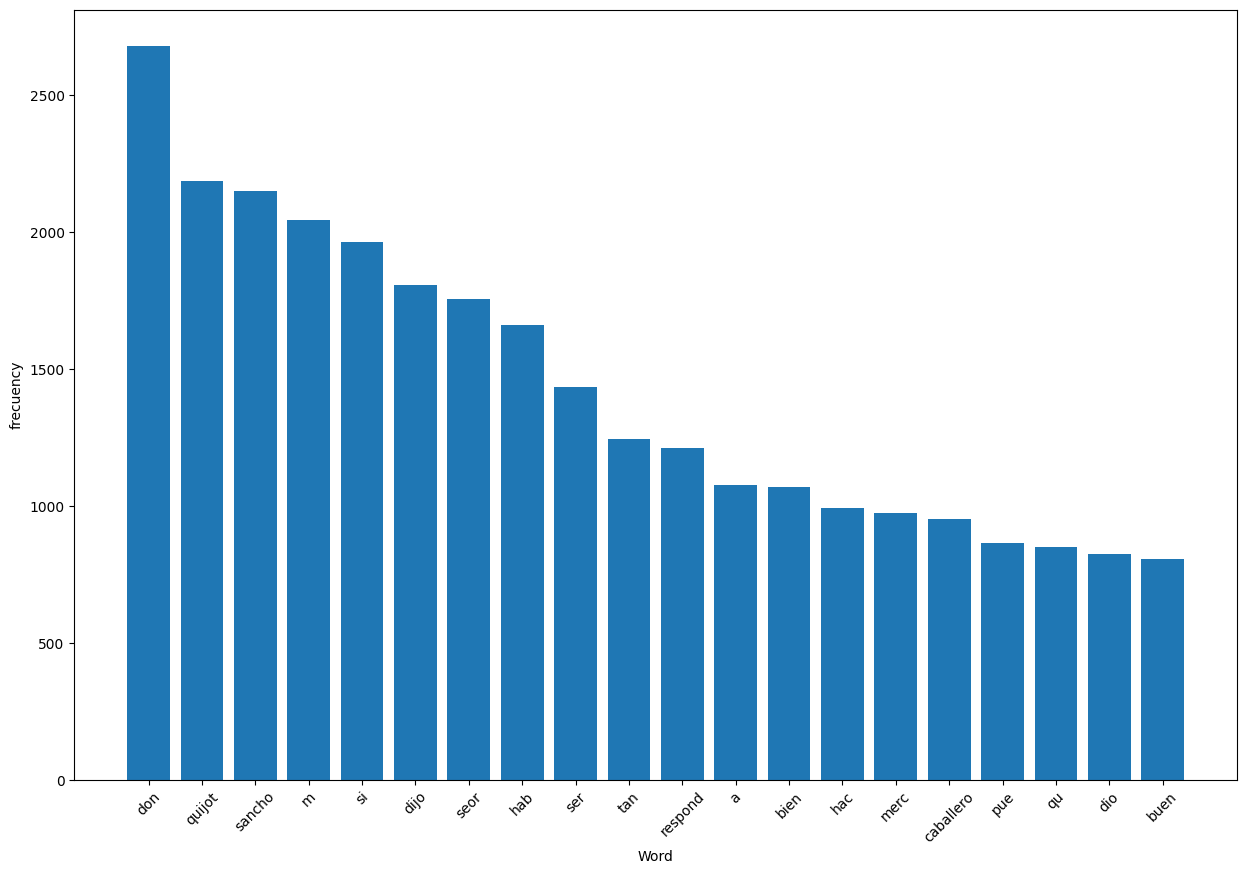

In [60]:
import matplotlib.pyplot as plt
df = pd.DataFrame(top_words)
plt.figure(figsize=(15,10))
plt.bar(df[0],df[1])
plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("frecuency")
plt.show()

In [61]:
# representacion BoW

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

corpus = [
    "El gato está durmiendo",
    "El perro está jugando",
    "El gato y el perro son amigos",
    "A los gatos les gusta dormir todo el día"
]

bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus)
df_bow = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())

print("\nBag of Words")
print(df_bow)


Bag of Words
   amigos  dormir  durmiendo  día  el  está  gato  gatos  gusta  jugando  les  \
0       0       0          1    0   1     1     1      0      0        0    0   
1       0       0          0    0   1     1     0      0      0        1    0   
2       1       0          0    0   2     0     1      0      0        0    0   
3       0       1          0    1   1     0     0      1      1        0    1   

   los  perro  son  todo  
0    0      0    0     0  
1    0      1    0     0  
2    0      1    1     0  
3    1      0    0     1  


In [62]:
# representación TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Ejemplo de documentos
corpus = [
    "El gato está durmiendo",
    "El perro está jugando",
    "El gato y el perro son amigos",
    "A los gatos les gusta dormir todo el día"
]

# using default tokenizer in TfidfVectorizer
tfidf = TfidfVectorizer(min_df=1, max_df=0.5, ngram_range=(1, 2))
features = tfidf.fit_transform(corpus)
df_tfidf = pd.DataFrame(
    features.todense(),
    columns=tfidf.get_feature_names_out()
)

print("\nTF-IDF")
print(df_tfidf.round(2))


TF-IDF
   amigos  dormir  dormir todo  durmiendo   día  el día  el gato  el perro  \
0    0.00    0.00         0.00       0.45  0.00    0.00     0.36      0.00   
1    0.00    0.00         0.00       0.00  0.00    0.00     0.00      0.36   
2    0.37    0.00         0.00       0.00  0.00    0.00     0.29      0.29   
3    0.00    0.27         0.27       0.00  0.27    0.27     0.00      0.00   

   está  está durmiendo  ...  les gusta   los  los gatos  perro  perro está  \
0  0.36            0.45  ...       0.00  0.00       0.00   0.00        0.00   
1  0.36            0.00  ...       0.00  0.00       0.00   0.36        0.45   
2  0.00            0.00  ...       0.00  0.00       0.00   0.29        0.00   
3  0.00            0.00  ...       0.27  0.27       0.27   0.00        0.00   

   perro son   son  son amigos  todo  todo el  
0       0.00  0.00        0.00  0.00     0.00  
1       0.00  0.00        0.00  0.00     0.00  
2       0.37  0.37        0.37  0.00     0.00  
3       0.00 

## Qué aprendimos en este lab
- El texto crudo no es usable directamente por modelos
- El preprocesamiento define el espacio de representación
- Decisiones simples (lowercase, stopwords) tienen impacto aguas abajo

- Reto corto – LAB 1 (apropiación conceptual)

- Toma el otros archivos diferentes del directorio 'datasets' y ejecuta dos pipelines distintos:
- Con stopwords
- Sin stopwords
- Pregunta:
- ¿En qué tipo de tareas conservarías las stopwords y por qué?
- Da un ejemplo concreto (clasificación, QA, IR, etc.).

- Responde aca mismo:
